In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path
from multiprocessing import Pool

import seaborn as sns

import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from scipy.stats import gaussian_kde, linregress, pearsonr, spearmanr

from exports_utils import load_bootstrap_bm_metrics, load_bootstrap_sr_metrics

from tqdm.auto import tqdm
tqdm.pandas()

THRESHOLD = 0.226

In [2]:
# Checkpoints

mm_cp_pa = '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31'
td_cp_pa = '37_mm4_transductif-2025-12-02_12-47'
td_cp_reg = '38_mm4_transductif_reg-2026-03-04_16-44'
td_cp_eco = '40_mm4_transductif_eco-2026-03-02_14-03'

In [3]:
# Load predictions

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

predictions = pd.read_csv(output_path / td_cp_pa / 'predictions-probs.csv', index_col='survey_id')
bm_predictions = pd.read_csv(output_path / td_cp_reg / 'predictions-biomass.csv', index_col='survey_id')

predictions_prev = (predictions > THRESHOLD).sum(axis=0)

In [4]:
# Load targets

input_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv') # _split.csv')
fulldf = pd.read_csv(input_path, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

species = predictions.columns
alltargets = fulldf[species]
testtargets = fulldf.loc[predictions.index, species]

## Dataset stats

In [ ]:
species_prev = (alltargets > 0).sum(axis=0) / alltargets.shape[0]
species_bm = alltargets.sum(axis=0)

alltargets[species].sum(axis=1).describe()

## Outputs visualization

#### Species richness

In [ ]:
predictions_sr = (predictions > THRESHOLD).sum(axis=1)
targets_sr = (testtargets > 0).sum(axis=1)

print(linregress(targets_sr, predictions_sr))

LinregressResult(slope=0.9006319539203141, intercept=2.721095854488034, rvalue=0.7879205214294985, pvalue=0.0, stderr=0.0100032680049999, intercept_stderr=0.2774968012985377)


In [16]:
fig = px.scatter(
    x=np.log(1+targets_sr), y=np.log(1+predictions_sr),
    marginal_y='violin', marginal_x='violin'
)

fig.update_layout(width=800, height=800)
fig.show()

[Text(0.5, 0, 'Ground truth species richness (logged)'),
 Text(0, 0.5, 'Predicted species richness (logged)')]

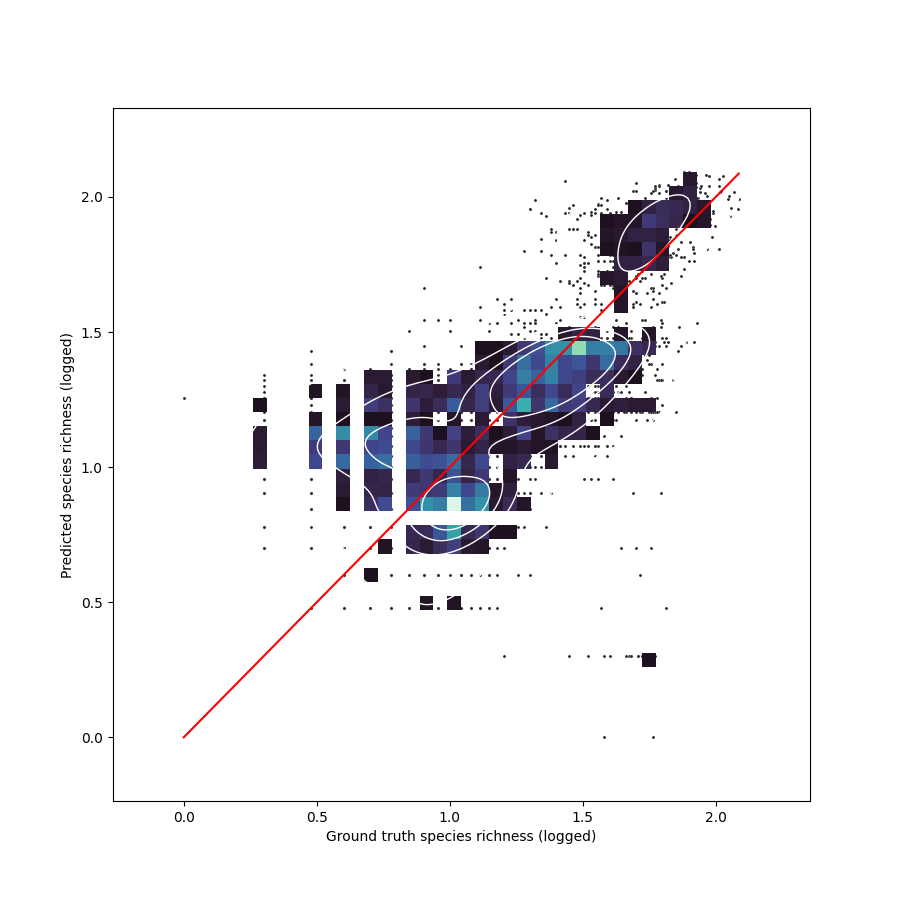

In [17]:
x, y = np.log10(1+targets_sr), np.log10(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='Ground truth species richness (logged)', ylabel='Predicted species richness (logged)')

## Embeddings

#### Embeddings comparison subset/td

In [ ]:
tv_emb = np.load(output_path / td_cp_pa / 'embedding_trainval.npy')
test_emb = np.load(output_path / td_cp_pa / 'embedding.npy')
td_emb = np.load(output_path / td_cp_pa / 'embedding_transductive.npy')

all_emb = np.concatenate([td_emb, tv_emb, test_emb], axis=0)

In [24]:
pca = PCA(n_components=2)
pca.fit(all_emb)
pca_emb = pca.transform(all_emb)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2'])
pca_pd['subset'] = ['transductive'] * len(td_emb) + ['trainval'] * len(tv_emb) + ['test'] * len(test_emb)


In [25]:

px.scatter(pca_pd, x='pc1', y='pc2', color='subset', width=1200, height=1200)

#### Embedding (clustering)

In [5]:
emb = np.load(output_path / mm_cp_pa / 'embedding.npy')
td_emb = np.load(output_path / td_cp_pa / 'embedding.npy')

In [6]:
test_df = fulldf[fulldf['subset'] == 'test']

pca = PCA(n_components=3)
pca.fit(emb)
pca_emb = pca.transform(emb)

td_pca = PCA(n_components=3)
td_pca.fit(td_emb)
td_pca_emb = td_pca.transform(td_emb)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2', 'pc3'], index = test_df.index)
td_pca_pd = pd.DataFrame(td_pca_emb, columns=['pc1', 'pc2', 'pc3'], index = test_df.index)

In [7]:
n_clusters = 9

clustering = AgglomerativeClustering(n_clusters=n_clusters)
cluster_labels = clustering.fit_predict(pca_pd[['pc1', 'pc2', 'pc3']])
pca_pd['cluster_label'] = cluster_labels

td_clustering = AgglomerativeClustering(n_clusters=n_clusters)
td_cluster_labels = td_clustering.fit_predict(td_pca_pd[['pc1', 'pc2', 'pc3']])
td_pca_pd['cluster_label'] = td_cluster_labels

In [8]:
#fig = px.scatter_3d(pca_pd, x='pc1', y='pc2', z='pc3', color='cluster_label', height = 600, width = 800, color_continuous_scale=px.colors.sequential.Turbo)

fig = make_subplots(rows=1, cols=2,specs=[[{'type': 'surface'}, {'type': 'surface'}]])

fig.add_trace(
    go.Scatter3d(x=pca_pd['pc1'], y=pca_pd['pc2'], z=pca_pd['pc3'], mode='markers',
                 marker=dict(color=pca_pd['cluster_label'], colorscale=px.colors.sequential.Turbo)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(x=td_pca_pd['pc1'], y=td_pca_pd['pc2'], z=td_pca_pd['pc3'], mode='markers',
                 marker=dict(color=td_pca_pd['cluster_label'], colorscale=px.colors.sequential.Turbo)),
    row=1, col=2
)

fig.update_layout(height=800, width=1400)
fig.show()

# fig.update_scenes(xaxis_title_font_color="blue",
#                   xaxis_tickfont_color="blue",
#                   yaxis_title_font_color="red",
#                   yaxis_tickfont_color="red",  
#                   zaxis_title_font_color="green",
#                   zaxis_tickfont_color="green",)


In [ ]:
to_export = pd.concat([pca_pd, test_df[['site_code', 'latitude', 'longitude', 'survey_date']]], axis=1)
to_export.to_csv(output_path / td_cp_pa / 'pca.csv')

#### Embeddings (vs colors)

In [ ]:
emb = np.load(output_path / mm_cp_pa / 'embedding.npy')
td_emb = np.load(output_path / td_cp_pa / 'embedding.npy')

env = pd.read_csv('/data/data/malpolon/xgb/X_compound_values_mm.csv', index_col='survey_id', usecols = list(range(20)) + [59])

env.columns = ["fsle", "fsle-orientation", "bathymetry", "chlorophyll", "sst", "salinity", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "protection-level", "distance-to-port", "population-density-log", "gravity", "dhw_max"]

ind = pd.read_csv('/data/data/RLS/eco_indicators.csv', index_col='survey_id')

In [14]:
test_df = fulldf[fulldf['subset'] == 'test']

pca = PCA(n_components=2)
pca.fit(emb)
pca_emb = pca.transform(emb)

td_pca = PCA(n_components=2)
td_pca.fit(td_emb)
td_pca_emb = td_pca.transform(td_emb)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2'], index = test_df.index)
td_pca_pd = pd.DataFrame(td_pca_emb, columns=['pc1', 'pc2'], index = test_df.index)

In [ ]:
# Plot vs predictors

USE_CASE = 'TRANSDUCTIVE' ## or INDUCTIVE

if USE_CASE == 'TRANSDUCTIVE':
    data = td_pca_pd
else:
    data = pca_pd

fig = make_subplots(rows=4, cols=5, subplot_titles=env.columns,
                    horizontal_spacing = 0.02, vertical_spacing=0.04)

for i in range(len(env.columns)):
    var = env.columns[i]
    fig.add_trace(
        go.Scatter( x=data['pc1'], y=data['pc2'], mode='markers',
                    marker=dict(color=env.loc[data.index, var], colorscale='Spectral')),
        row= 1 + i // 5, col=1 + i % 5
    )

fig.update_layout(height=1200, width=1500, showlegend=False)
fig.show()

In [28]:
# Plot vs indicators

USE_CASE = 'TRANSDUCTIVE' ## or INDUCTIVE

if USE_CASE == 'TRANSDUCTIVE':
    data = td_pca_pd
else:
    data = pca_pd

fig = make_subplots(rows=2, cols=5, subplot_titles=ind.columns,
                    horizontal_spacing = 0.02, vertical_spacing=0.1)

for i in range(len(ind.columns)):
    var = ind.loc[data.index].columns[i]
    fig.add_trace(
        go.Scatter( x=data['pc1'], y=data['pc2'], mode='markers',
                    marker=dict(color=ind.loc[data.index, var], colorscale='Spectral')),
        row= 1 + i // 5, col=1 + i % 5
    )

fig.update_layout(height=700, width=1500, showlegend=False)
fig.show()

#### Multivariate correlation

In [7]:
n_components = 5
td_emb = np.load(output_path / '37_mm4_transductif-2025-12-02_12-47' / 'embedding.npy')

test_df = fulldf[fulldf['subset'] == 'test']

# Embeddings + PCA
td_pca = PCA(n_components=n_components)
td_pca.fit(td_emb)
total_explained = sum(td_pca.explained_variance_ratio_)
td_pca_emb = td_pca.transform(td_emb)
td_pca_pd = pd.DataFrame(td_pca_emb, columns=[f"pc{i+1}" for i in range(td_pca_emb.shape[1])], index = test_df.index)

# Predictors
env = pd.read_csv('/data/data/malpolon/xgb/X_compound_values_mm.csv', index_col='survey_id', usecols = list(range(20)) + [59])
env.columns = ["fsle", "fsle-orientation", "bathymetry", "chlorophyll", "sst", "salinity", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "protection-level", "distance-to-port", "population-density-log", "gravity", "dhw_max"]

predictors = env.loc[test_df.index]

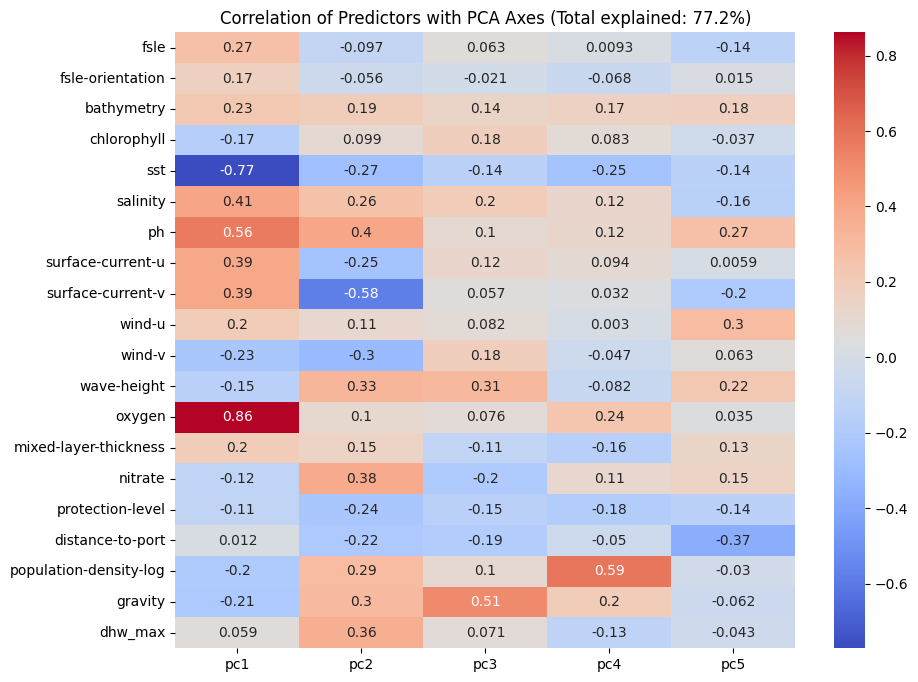

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Compute correlation matrix: predictors vs PCA axes
corr_matrix = pd.DataFrame(index=predictors.columns, columns=td_pca_pd.columns)
for pc in td_pca_pd.columns:
    corr_matrix[pc] = predictors.apply(lambda x: x.corr(td_pca_pd[pc]))


# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", )
plt.title(f"Correlation of Predictors with PCA Axes (Total explained: {100*total_explained:.1f}%)")
plt.show()

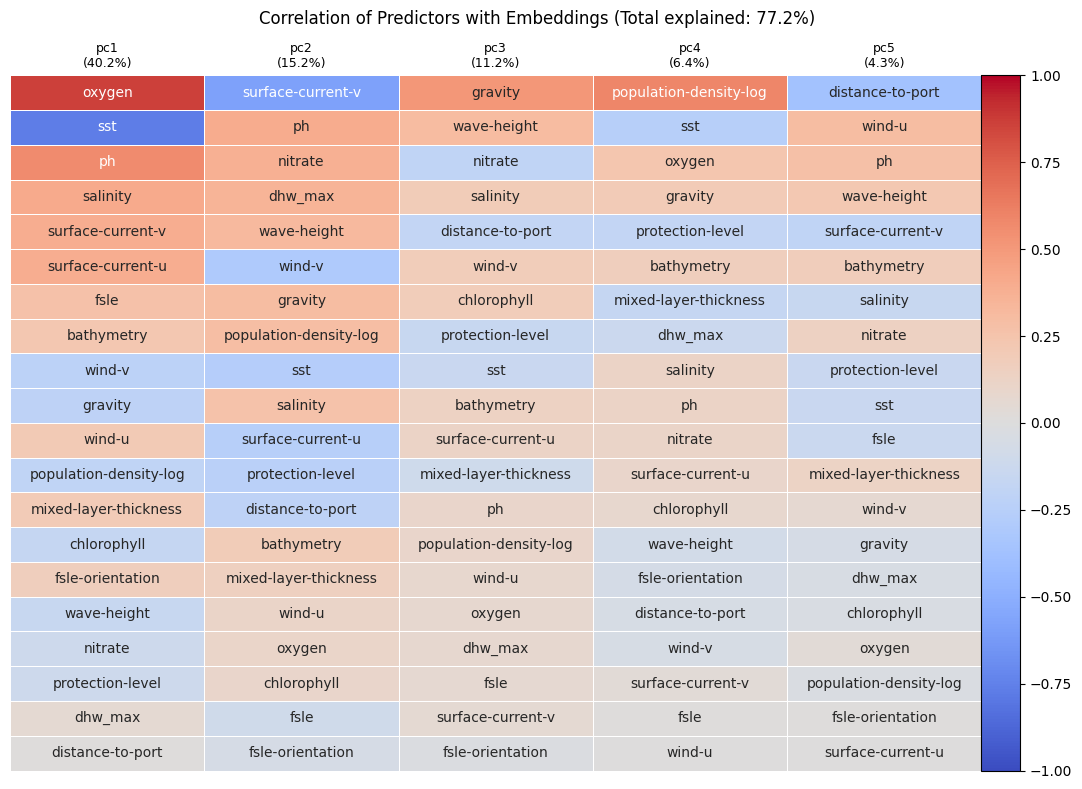

In [21]:
n_vars = corr_matrix.shape[0]

fig, axes = plt.subplots(1, n_components + 1, figsize=(2 * n_components + 1, 8),
                         gridspec_kw={"width_ratios": [1] * n_components + [0.2]})

for i, (ax, pc) in enumerate(zip(axes, corr_matrix.columns)):
    # Sort rows by absolute correlation, descending
    col = corr_matrix[[pc]].sort_values(by=pc, key=abs, ascending=False)

    # Cell labels = variable names
    labels = pd.DataFrame(
        col.index.tolist(),
        index=col.index,
        columns=[pc]
    )

    sns.heatmap(
        col,
        annot=labels,
        fmt="",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax,
        cbar=False
    )

    # Title includes explained variance
    var_explained = td_pca.explained_variance_ratio_[i] * 100
    ax.set_title(f"{pc}\n({var_explained:.1f}%)", fontsize=9)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.tick_params(left=False, bottom=False)
    #ax.spines["left"].set_visible(False)


# Add a single shared colorbar in the last axis
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
mpl.colorbar.ColorbarBase(axes[-1], cmap=plt.cm.coolwarm, norm=norm)


plt.suptitle(f"Correlation of Predictors with Embeddings (Total explained: {100*total_explained:.1f}%)")
plt.tight_layout()
plt.subplots_adjust(wspace=0)
plt.show()

In [ ]:
# Plot vs predictors

data = td_pca_pd


fig = make_subplots(rows=4, cols=5, subplot_titles=env.columns,
                    horizontal_spacing = 0.02, vertical_spacing=0.04)

for i in range(len(env.columns)):
    var = env.columns[i]
    fig.add_trace(
        go.Scatter( x=data['pc1'], y=data['pc2'], mode='markers',
                    marker=dict(color=env.loc[data.index, var], colorscale='Spectral')),
        row= 1 + i // 5, col=1 + i % 5
    )

fig.update_layout(height=1200, width=1500, showlegend=False)
fig.show()

## Traits

#### Load traits

In [6]:
traits = pd.read_csv('/data/data/RLS/traits.csv', index_col=0)

troph_level_dict = {s: traits['Troph'].get(s, np.nan) for s in species}
troph_level = pd.Series(troph_level_dict, index = species, name = 'troph_level')

uicnL_status_dict = {s: traits['IUCN_inferred_Loiseau23'].get(s, 'No Status') for s in species}
uicnL_status = pd.Series(uicnL_status_dict, index = species, name = 'uicnL_status')
uicnL_threatened = pd.Series([(uicnL_status_dict[s] == 'Threatened')*1 for s in species], index = species, name = 'Threatened')

uicn_species = list(uicnL_threatened[uicnL_threatened == 1].index)

importance_dict = {s: traits['Importance'].get(s, np.nan) for s in species}
importance = pd.Series(importance_dict, index = species, name = 'Importance')

## Export metrics

#### F1 by site

In [5]:
td_cp_pa = '42_td_pa_seedtest-2026-03-11_14-31'
ind_cp_pa = '42_ind_pa_seedtest-2026-03-12_17-19'

In [6]:
# F1 by site
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

for i in range(1,6):

    predictions = pd.read_csv(output_path / ind_cp_pa / f"Seed-{i}" / 'predictions-probs.csv', index_col='survey_id')
    f1scores = []
    test_df = fulldf[fulldf['subset'] == 'test']

    for site in test_df['site_code'].unique():
        surveys = test_df[test_df['site_code'] == site].index
        lat, lon = test_df.loc[surveys[0], 'latitude'], test_df.loc[surveys[0], 'longitude']
        preds = (predictions > THRESHOLD).astype(float).loc[surveys].to_numpy().flatten()
        targets = (test_df != 0).astype(float).loc[surveys, predictions.columns].to_numpy().flatten()
        f1 = f1_score(targets, preds)
        f1scores.append({'site':site, 'f1':f1, 'lat':lat, 'lon':lon})

    pd.DataFrame(f1scores).to_csv(output_path / ind_cp_pa / f"Seed-{i}" / 'f1_by_site_new.csv')


In [7]:
# Average all:
# output_path = Path('/marbec-data/RLS-Australia/malpolon/xgb/pa')

df_list = []

for i in range(1,6):

    f1s = pd.read_csv(output_path / ind_cp_pa / f"Seed-{i}" / 'f1_by_site_new.csv', index_col='site')
    #f1s = pd.read_csv(next((output_path / f"Seed-{i}" ).glob("xgb_best_f1*.csv")), index_col = 0)
    df_list.append(f1s["f1"])
    
all_df = pd.concat(df_list, axis = 1).T
y_mean = all_df.mean(axis=0)
y_std  = all_df.std(axis=0)
y_sem  = y_std / np.sqrt(len(df_list))  # standard error

# 95% confidence interval (normal approx): mean ± 1.96 * SEM 
ci = 1.96 * y_sem

pd.concat([y_mean, ci], axis = 1, keys=['mean', 'ci']).to_csv(output_path / ind_cp_pa / 'f1_by_site.csv')

In [ ]:
pd.DataFrame(f1scores).describe()

#### Best UICN species

In [ ]:
td_f1 = pd.read_csv(next((output_path / td_cp_pa).glob("testF1*.csv")), index_col = 0)
uicn_f1 = td_f1[uicnL_status == 'Threatened'] ### Load from below

uicn_f1.index.tolist()[:4]

#### Best commercial species

In [ ]:
td_r2 = pd.read_csv(next((output_path / td_cp_reg).glob("testR2*.csv")), index_col = 0)
td_r2['Importance'] = importance.loc[td_r2.index] ### Load from below

td_r2.head(20)

## Calculate ecological indicators

In [7]:
def iucn_sr(row):
    present_species = row[row > 0].index
    if len(row[row > 0]) == 0:
        return 0
    return uicnL_threatened.loc[present_species].sum()

def av_troph(row):
    present_species = row[row > 0].index
    trop_values = troph_level.loc[present_species].dropna()
    if len(trop_values) == 0:
        return 0
    return trop_values.mean()

def std_troph(row):
    present_species = row[row > 0].index
    trop_values = troph_level.loc[present_species].dropna()
    if len(trop_values) <= 1:
        return 0
    return trop_values.std()

#### Groundtruth

In [8]:
input_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')
fulldf = pd.read_csv(input_path, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

first_species_index = list(fulldf.columns).index('eventDate') + 1
species = fulldf.columns[first_species_index:-1]

In [11]:
## All indicators

out = fulldf[['latitude', 'longitude', 'depth']]
out = out.assign(year=pd.to_datetime(fulldf['eventDate']).dt.year)
month = pd.to_datetime(fulldf['eventDate']).dt.month - 1
out['season'] = 0.5-0.5*np.cos(np.pi*month / 6)
out['sr'] = (fulldf[species] > 0).sum(axis=1)
out['bm'] = fulldf[species].sum(axis=1)
out['av_troph'] = (fulldf[species] > 0).apply(av_troph, axis=1)
out['std_troph'] = (fulldf[species] > 0).apply(std_troph, axis=1)
out['uicn_sr'] = (fulldf[species] > 0).apply(iucn_sr, axis=1)

#out.to_csv('/data/data/RLS/eco_indicators.csv')

In [12]:
## Groundtruth
output = pd.DataFrame()
output['eventDate'] = pd.Series('', index = out.index)
output['log_sr'] = np.log(out['sr'] + 1)
output['log_bm'] = np.log(out['bm'] + 1)
output['log_uicn_sr'] = np.log(out['uicn_sr'] + 1)
output['subset'] = fulldf.loc[output.index, 'subset']

#output.to_csv(input_path.parent / 'eco_indic.csv')

# Normalize

output_norm = pd.DataFrame()
output_norm['eventDate'] = pd.Series('', index = out.index)
output_norm['log_sr'] = output['log_sr'] / output['log_sr'].max()
output_norm['log_bm'] = output['log_bm'] / output['log_bm'].max()
output_norm['log_uicn_sr'] = output['log_uicn_sr'] / output['log_uicn_sr'].max()
output_norm['subset'] = output['subset']

#output[['log_sr', 'log_bm', 'log_uicn_sr']].max().to_csv(input_path.parent / 'eco_indic_maxima.csv')
#output_norm.to_csv(input_path.parent / 'eco_indic_norm.csv')

#### Predictions

In [ ]:
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

td_cp_pa = '42_td_pa_seedtest-2026-03-11_14-31'
td_cp_reg = '42_td_reg_seedtest-2026-03-12_10-21'

log_bm_preds_mean, log_bm_preds_ci = load_bootstrap_bm_metrics(output_path, td_cp_reg)
log_sr_preds_mean, log_sr_preds_ci = load_bootstrap_sr_metrics(output_path, td_cp_pa)
log_uicn_sr_preds_mean, log_uicn_sr_preds_ci = load_bootstrap_sr_metrics(output_path, td_cp_pa, uicn = True)


In [33]:
eco_maxima = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/eco_indic_maxima.csv', index_col=0)

## Predictions 
out_preds = pd.DataFrame()

out_preds['log_sr_mean'] = log_sr_preds_mean
out_preds['log_sr_ci'] = log_sr_preds_ci

out_preds['log_bm_mean'] = log_bm_preds_mean
out_preds['log_bm_ci'] = log_bm_preds_ci

out_preds['log_uicn_sr_mean'] = log_uicn_sr_preds_mean
out_preds['log_uicn_sr_ci'] = log_uicn_sr_preds_ci

out_preds.to_csv(output_path / td_cp_pa / 'eco_indic.csv')

out_preds_norm = pd.DataFrame()
out_preds_norm['log_sr_mean'] = out_preds['log_sr_mean'] / eco_maxima.loc['log_sr', '0']
out_preds_norm['log_sr_ci'] = out_preds['log_sr_ci'] / eco_maxima.loc['log_sr', '0']

out_preds_norm['log_bm_mean'] = out_preds['log_bm_mean'] / eco_maxima.loc['log_bm', '0']
out_preds_norm['log_bm_ci'] = out_preds['log_bm_ci'] / eco_maxima.loc['log_bm', '0']

out_preds_norm['log_uicn_sr_mean'] = out_preds['log_uicn_sr_mean'] / eco_maxima.loc['log_uicn_sr', '0']
out_preds_norm['log_uicn_sr_ci'] = out_preds['log_uicn_sr_ci'] / eco_maxima.loc['log_uicn_sr', '0']

out_preds_norm.to_csv(output_path / td_cp_pa / 'eco_indic_norm.csv')

scores = {'log_sr':{'mean': pearsonr(output_norm.loc[out_preds.index,'log_sr'], out_preds_norm['log_sr_mean'])[0],
                    'min': pearsonr(output_norm.loc[out_preds.index,'log_sr'],
                                    np.clip(out_preds_norm['log_sr_mean'] - out_preds_norm['log_sr_ci'], 0, 1))[0],
                    'max': pearsonr(output_norm.loc[out_preds.index,'log_sr'], out_preds_norm['log_sr_mean'] + out_preds_norm['log_sr_ci'])[0]},
          'log_bm':{'mean': pearsonr(output_norm.loc[out_preds.index,'log_bm'], out_preds_norm['log_bm_mean'])[0],
                    'min': pearsonr(output_norm.loc[out_preds.index,'log_bm'],
                                    np.clip(out_preds_norm['log_bm_mean'] - out_preds_norm['log_bm_ci'], 0, 1))[0],
                    'max': pearsonr(output_norm.loc[out_preds.index,'log_bm'], out_preds_norm['log_bm_mean'] + out_preds_norm['log_bm_ci'])[0]},
          'log_uicn_sr':{'mean': pearsonr(output_norm.loc[out_preds.index,'log_uicn_sr'], out_preds_norm['log_uicn_sr_mean'])[0],
                         'min': pearsonr(output_norm.loc[out_preds.index,'log_uicn_sr'],
                                         np.clip(out_preds_norm['log_uicn_sr_mean'] - out_preds_norm['log_uicn_sr_ci'], 0, 1))[0],
                         'max': pearsonr(output_norm.loc[out_preds.index,'log_uicn_sr'], out_preds_norm['log_uicn_sr_mean'] + out_preds_norm['log_uicn_sr_ci'])[0]}
          }


pd.DataFrame(scores).T.sort_values('mean', ascending=False).to_csv(output_path / td_cp_pa / 'eco_indic_corr.csv')
print(pd.DataFrame(scores).T)

                 mean       min       max
log_sr       0.489832  0.376034  0.583299
log_bm       0.592367  0.594071  0.587447
log_uicn_sr  0.482121  0.138269  0.506805


## Eco

In [ ]:
td_cp_eco = '42_td_eco_seedtest-2026-03-10_14-13'

eco_maxima = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/eco_indic_maxima.csv', index_col=0)
eco_targets = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/eco_indic_norm.csv', index_col=0)

#### Calculate calibration values on val

In [62]:
print(val_preds.describe())
print(val_targets.describe())

            log_sr       log_bm  log_uicn_sr
count  8601.000000  8601.000000  8601.000000
mean      5.894829   788.349101     0.409171
std       2.734591   394.107423     0.229688
min       3.314148   406.587171     0.162941
25%       3.388774   417.293469     0.217352
50%       5.234591   704.353192     0.298637
75%       7.241908  1003.467093     0.583539
max      15.544740  2201.024857     1.171369
            log_sr        log_bm  log_uicn_sr
count  8601.000000  8.601000e+03  8601.000000
mean     19.338100  3.869120e+04     0.961865
std      15.899667  8.684835e+04     1.108083
min       0.000000  0.000000e+00     0.000000
25%       8.000000  6.856437e+03     0.000000
50%      14.000000  1.669531e+04     1.000000
75%      24.000000  3.927539e+04     2.000000
max     101.000000  2.761536e+06     6.000000


In [24]:
corrections = {}

for seed in range(1, 6):

    trainval_preds = pd.read_csv(output_path / td_cp_eco / f"Seed-{seed}" / 'predictions-biomass.csv', index_col='survey_id')
    val_preds = trainval_preds.loc[fulldf['subset'] == 'test']
    val_preds = np.exp(val_preds * eco_maxima['0']) - 1

    val_targets = np.exp(eco_targets.loc[val_preds.index, val_preds.columns] * eco_maxima['0']) - 1

    d = {}

    for s in val_preds.columns:
        nonzero = (val_targets[s] > 0) * (val_preds[s] > 0)
        slope, intercept, r_value, _, _ = linregress(val_preds[s][nonzero], val_targets[s][nonzero])
        d[s] = {'slope': slope, 'intercept': intercept, 'r_value': r_value}

    pd.DataFrame(d).T.sort_values('r_value', ascending=False).to_csv(output_path / td_cp_eco / f"Seed-{seed}" / 'corrections.csv')

## Old

#### Interpretability

In [ ]:
best_species = pd.read_csv(output_path / td_cp_pa / 'best_species.csv', index_col = 0)
species = list(best_species.index)
ig_path = output_path / td_cp_pa / 'integrated_gradients'

labels = ["fsle", "fsle-orientation", "bathymetry_aus", "chlorophyll", "sst", "salinity3d", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "prot_level", "distance-to-port", "pop-density-log", "gravity"]

In [ ]:
colors = plotly.colors.qualitative.Light24

def produce_charts(speci):

    presences = []
    absences = []
    for survey_id in list(targets.index):

        ig = np.load(ig_path / speci / f"ig_{survey_id}.npy")

        abs_ig = np.abs(ig).squeeze()
        averages = abs_ig.mean(axis=(1,2))

        if fulldf.loc[survey_id, s] > 0:
            presences.append(averages)
        else:
            absences.append(averages)

    
    presences = np.vstack(presences)
    absences = np.vstack(absences)

    p = pd.DataFrame(presences)
    a = pd.DataFrame(absences)
    a.columns = labels
    p.columns = labels

    fig = make_subplots(rows=2, cols=1, subplot_titles=("Presence", "Absence"))

    # Plot density for each column
    for i in range(len(a.columns)):
        column = a[s].columns[i]

        density = gaussian_kde(p[column])
        xs = np.linspace(p[column].min(), p[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=1, col=1)

        density = gaussian_kde(a[column])
        xs = np.linspace(a[column].min(), a[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=2, col=1)

    # Update layout
    fig.update_layout(title=speci,
                    xaxis_title='Value',
                    yaxis_title='Density',
                    template='plotly_white',
                    height = 800)

    # Show plot
    fig.update_yaxes(range=[0, 600]) 
    fig.update_xaxes(range=[0, 0.03]) 
    fig.write_image(output_path / td_cp_pa / "ig_densities" / f"{speci}.png")

In [ ]:
with Pool(processes=18) as pool:
        results = pool.map(produce_charts, species)

In [ ]:
series_dict = {}

for i in range(len(species)):
    s = species[i]
    p = Path(output_path / ig_name / "ig_stats" / f"{s}_pres.csv")
    if p.exists():
        df = pd.read_csv(p, index_col = 0)
        series_dict[s] = df['50%']

df = pd.concat(series_dict, axis = 1).T
df.sort_values(ascending=False, by = 'bathymetry_aus', inplace = True)
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df.T, ax = ax, cbar=False, cmap='YlOrRd')
plt.tight_layout()

#### Compare checkpoints

In [ ]:
checkpoints = {'9_env_pa-2025-02-04_16-46-preds' : 'Environment17',
               '10_sat_pa-2025-02-05_17-32-preds' : 'Satellite',
               '11_satenv_pa-2025-02-06_11-50-preds' : 'Environment + Satellite',
               '9_env_pa-2025-03-11_10-31-preds' : 'Environment15',
               '13_hum_pa-2025-03-11_10-29-preds' : 'Human activities',
               '15_humenv_cat_pa-2025-03-11_10-32-preds' : 'Environment + Human activities<br><b>monomodal</b>',
               '14_humenv_pa-2025-03-04_11-45-preds' : 'Environment + Human activities<br><b>multimodal</b>',
               '18_humenv_dhw_cat_pa-2025-05-16_12-02-preds' : 'Envhum+DHW',
               '20_humenv_best10_pa-2025-05-16_14-50-preds' : 'Envhum+Best10',
               '22_humenv_dhw_best10_pa-2025-05-16_13-47-preds': 'Envhum+DHW+Best10',
               '23_humenv_dhw_best30_pa-2025-05-21_09-48-preds': 'Envhum+DHW+Best30',
               }

checkpoints = {'18_humenv_dhw_cat_pa-2025-07-07_16-55-preds': 0,
               #'18_humenv_dhw_cat_pa-2025-07-02_16-41-preds': .011111,
            #   '18_humenv_dhw_cat_pa-2025-07-08_09-39-preds': .01,
            #    '18_humenv_dhw_cat_pa-2025-07-08_09-29-preds': .2,
            #    '18_humenv_dhw_cat_pa-2025-07-08_10-14-preds': .04,
            #   '18_humenv_dhw_cat_pa-2025-07-08_10-58-preds': .1,
            #    '18_humenv_dhw_cat_pa-2025-07-08_12-50-preds': 0.025,
            #   '18_humenv_dhw_cat_pa-2025-07-08_13-49-preds': 0.001,
            #    '18_humenv_dhw_cat_pa-2025-07-08_15-24-preds': 0.004,
            #    '18_humenv_dhw_cat_pa-2025-07-08_16-41-preds': 0.08,
            '18_humenv_dhw_cat_pa-2025-07-09_13-48-preds': 0.1,
            '18_humenv_dhw_cat_pa-2025-07-09_14-39-preds': 0.02,
            '18_humenv_dhw_cat_pa-2025-07-09_15-30-preds': 0.5,}
            # '18_humenv_dhw_cat_pa-2025-07-09_16-22-preds': 2}


points = []

for cp in checkpoints:
    try:
        predictions = pd.read_csv(output_path / cp / 'predictions-probs.csv', index_col='survey_id')
    except Exception as e:
        predictions = pd.read_csv(output_path / cp / 'predictions.csv', index_col='survey_id')
    predictions = (predictions >= THRESHOLD).astype(int)

    f1 = f1_score(targets_pres, predictions, average='weighted')
    macacc = balanced_accuracy_score(targets_pres.to_numpy().flatten(), predictions.to_numpy().flatten())
    FP = ((targets_pres == 0) & (predictions == 1)).to_numpy().sum() / (targets_pres == 0).to_numpy().sum()
    FN = ((targets_pres == 1) & (predictions == 0)).to_numpy().sum() / (targets_pres == 1).to_numpy().sum()
    points.append({'f1': f1, 'macro_acc':macacc, 'label': checkpoints[cp], 'False Positives':FP, 'False Negatives':FN})
    

In [ ]:
data = pd.DataFrame(points)
data['size'] = 12

fig = px.scatter(data,
                 x='False Positives',
                 y='False Negatives',
                 color='label',
                 text='label',
                 size = 'size',
                 template='simple_white',
                 width=800,
                 height=600)

fig.update_layout(showlegend=False)
# fig.update_yaxes(   scaleanchor="x",
#                     scaleratio=1)
fig.update_traces(textposition='middle right',  textfont=dict(size=20))

data = data.sort_values(by="label")

fig.add_traces(list(px.line(data, x='False Positives', y='False Negatives').select_traces()))
fig.update(layout_coloraxis_showscale=False)

fig.show()

#### Biomass

In [ ]:
maxima = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm_maxima.csv', index_col=0)['0']
preds = (np.exp(maxima*bm_predictions) - 1) #* corrections['slope'] + corrections['intercept']
#preds.clip(lower=0, inplace=True)

In [ ]:
d = {}

for s in species:
    pears = pearsonr(preds[s], testtargets[s])[0]
    spear = spearmanr(preds[s], testtargets[s])[0]
    d[s] = {'pearsonr': pears, 'spearmanr': spear}
    
metrics = pd.DataFrame(d).T.sort_values('pearsonr', ascending=False)
metrics

In [ ]:
nonzeropreds = preds.values.flatten()[preds.values.flatten() > 0]
nonzerotargets = testtargets.values.flatten()[preds.values.flatten() > 0]
pearsonr(nonzeropreds, nonzerotargets)

In [ ]:
x, y = np.log(1+nonzerotargets), np.log(1+nonzeropreds)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(18, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='Ground truth species richness (logged)', ylabel='Predicted species richness (logged)')

In [ ]:
dic = {}
for s in bm_predictions.columns:
    nonzeropreds = bm_predictions.loc[bm_predictions[s] > 0, s]
    nonzerotargets = testtargets.loc[bm_predictions[s] > 0, s]
    dic[s] = {'pearsonr': pearsonr(nonzerotargets, nonzeropreds)[0],
                'spearmanr': spearmanr(nonzerotargets, nonzeropreds)[0]}
    
scores = pd.DataFrame(dic).T
scores.sort_values(ascending=False, by='pearsonr', inplace = True)
scores.describe()